In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np

In [5]:
A=pd.read_excel("/content/A.xlsx")
B=pd.read_excel("/content/B.xlsx")
C=pd.read_excel("/content/C.xlsx")
D=pd.read_excel("/content/D.xlsx")

[Client A] after oversampling → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after oversampling → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after oversampling → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after oversampling → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5045 → 0.5950 | ΔW=1.3448

=== Round 2 ===
[Round 2] Global Accuracy: 0.5950 → 0.6146 | ΔW=0.1111

=== Round 3 ===
[Round 3] Global Accuracy: 0.6146 → 0.6203 | ΔW=0.1098

=== Round 4 ===
[Round 4] Global Accuracy: 0.6203 → 0.6357 | ΔW=0.0965

=== Round 5 ===
[Round 5] Global Accuracy: 0.6357 → 0.6278 | ΔW=0.1148

=== Round 6 ===
[Round 6] Global Accuracy: 0.6278 → 0.6301 | ΔW=0.1355

=== Round 7 ===
[Round 7] Global Accuracy: 0.6301 → 0.6369 | ΔW=0.0966

=== Round 8 ===
[Round 8] Global Accuracy: 0.6369 → 0.6440 | ΔW=0.0877

=== Round 9 ===
[Round 9] Global Accuracy: 0.6440 → 0.6459 | ΔW=0.0938

=== Round 10 ===


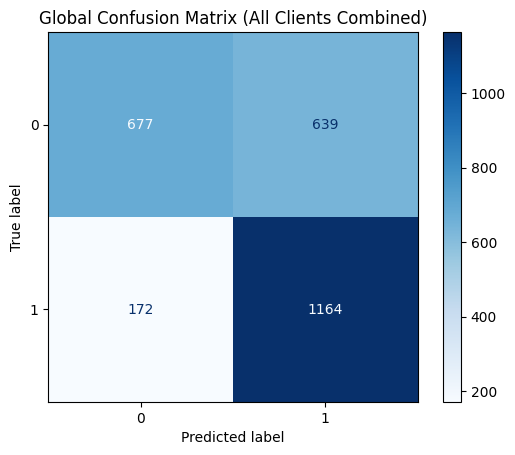


Final Global Accuracy (thr=0.35): 0.6942

[Global Classification Report]
              precision    recall  f1-score   support

           0     0.7974    0.5144    0.6254      1316
           1     0.6456    0.8713    0.7416      1336

    accuracy                         0.6942      2652
   macro avg     0.7215    0.6928    0.6835      2652
weighted avg     0.7209    0.6942    0.6840      2652



In [6]:
# ============================================================
# Federated Learning (TabNet) + αᵢ Mitigation + Imbalance Handling (FocalLoss + Oversampling + Threshold Auto-Tuning)
# ============================================================
# 임계값 최적화 해서 알아서 조절하는 버전
import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from imblearn.over_sampling import RandomOverSampler

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']


# ------------------------------------------------
# 1) 데이터 로드 + Oversampling
# ------------------------------------------------
# 오버샘플링
def oversample_dataset(X, y):
    ros = RandomOverSampler(random_state=42)
    X_res, y_res = ros.fit_resample(X, y)
    return X_res, y_res


def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values
    X = df.drop(columns=DEFECT_LABELS, errors='ignore')
    X = (
        X.select_dtypes(include=[np.number])
        .replace([np.inf, -np.inf], np.nan)
        .dropna(axis=0, how='any') # 결측치가 있는 행 전부 제거
    )
    y = y[:len(X)]

    # oversampling 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res


def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after oversampling → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    clients, metas = {}, {}

    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test], generator=torch.Generator().manual_seed(42))
        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {"n_samples": len(y), "class_counts": pd.Series(v["y"]).value_counts().to_dict()}

    return clients, metas, list(cols)


# ------------------------------------------------
# 2) TabNet 구조 정의
# ------------------------------------------------
def sparsemax(logits, dim=-1):
    z = logits
    z_sorted, _ = torch.sort(z, dim=dim, descending=True)
    dim_size = z.size(dim)
    range_vals = torch.arange(1, dim_size + 1, device=z.device, dtype=z.dtype).view(*([1] * (z.dim() - 1)), dim_size)
    zs_cumsum = torch.cumsum(z_sorted, dim=dim)
    k = (1 + range_vals * z_sorted > zs_cumsum).type(z.dtype)
    k_max = torch.max(range_vals * k, dim=dim, keepdim=True)[0]
    zs_cumsum_k = torch.gather(zs_cumsum, dim, (k_max.long() - 1))
    tau = (zs_cumsum_k - 1) / k_max
    output = torch.clamp(z - tau, min=0)
    return output


class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2)
    def forward(self, x):
        x = self.fc(x)
        x = self.bn(x)
        out, gate = x.chunk(2, dim=-1)
        return out * torch.sigmoid(gate)


class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, n_d, n_a, n_shared=1, n_independent=1):
        super().__init__()
        self.n_d, self.n_a = n_d, n_a
        self.shared = nn.ModuleList()
        for i in range(n_shared):
            in_dim = input_dim if i == 0 else n_d + n_a
            self.shared.append(GLUBlock(in_dim, n_d + n_a))
        self.indep = nn.ModuleList()
        for _ in range(n_independent):
            self.indep.append(GLUBlock(n_d + n_a, n_d + n_a))
    def forward(self, x):
        out = x
        for block in self.shared: out = block(out)
        for block in self.indep: out = block(out)
        return out


class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, feature_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)
    def forward(self, x, prior):
        x = self.fc(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = x * prior
        mask = sparsemax(x, dim=-1)
        return mask


class SimpleTabNet(nn.Module):
    def __init__(self, input_dim, num_classes=2, n_d=16, n_a=16, n_steps=3, gamma=1.3):
        super().__init__()
        self.input_dim, self.num_classes = input_dim, num_classes
        self.n_d, self.n_a, self.n_steps, self.gamma = n_d, n_a, n_steps, gamma
        self.decision_layers = nn.ModuleList([FeatureTransformer(input_dim, n_d, n_a) for _ in range(n_steps)])
        self.att = AttentiveTransformer(n_d, input_dim)
        self.fc_out = nn.Linear(n_d, num_classes)
    def forward(self, x):
        batch_size = x.size(0)
        prior = torch.ones(batch_size, self.input_dim, device=x.device)
        aggregated = torch.zeros(batch_size, self.n_d, device=x.device)
        x_flat, decision = x, None
        for step in range(self.n_steps):
            mask = sparsemax(x_flat, dim=-1) if step == 0 else self.att(decision, prior)
            masked_x = x_flat * mask
            h = self.decision_layers[step](masked_x)
            d, a = h[:, :self.n_d], h[:, self.n_d:]
            decision = d
            aggregated += decision
            prior = prior * (self.gamma - mask)
        return self.fc_out(aggregated)


# ------------------------------------------------
# 3) Focal Loss 정의
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')
    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()


# ------------------------------------------------
# 4) αᵢ 계산 함수 (nᵢ, cᵢ, tᵢ)
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K, total = len(class_counts), sum(class_counts.values())
    if K == 0 or total == 0: return 1e-8
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)
    logK = math.log(K + 1e-12)
    H_tilde = max(H, eps_frac * logK)
    frac_k = sum(1 for c in class_counts.values() if c >= min_samples) / K
    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components, rho=1.0, beta=0.7, theta=0.5):
    if not state_dicts: return None
    logits = {cid: math.log(comp["n_i"] ** rho + 1e-12)
                   + math.log(comp["c_i"] ** beta + 1e-12)
                   + math.log(comp["t_i"] ** theta + 1e-12)
              for cid, comp in alpha_components.items()}
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}
    global_sd = None
    for cid, sd in state_dicts.items():
        w = alphas[cid]
        if global_sd is None:
            global_sd = {k: v.clone() * w for k, v in sd.items()}
        else:
            for k in global_sd: global_sd[k] += sd[k] * w
    return global_sd


# ------------------------------------------------
# 5) Local Train & Evaluate (Threshold Auto-Tuning 포함)
# ------------------------------------------------
def local_train(model, dataset, lr, epochs, device):
    model = copy.deepcopy(model).to(device)
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = FocalLoss(alpha=2.0, gamma=2.0)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
    return model.state_dict()


def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()
    acc = (np.array(y_true) == np.array(y_pred)).mean()
    if return_preds: return acc, y_true, y_pred
    return acc


def find_best_threshold(model, dataset, device, thresholds=np.arange(0.3, 0.51, 0.05)):
    """0.3~0.5 구간에서 F1-score 기준 최적 threshold 탐색"""
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, y_true, y_pred = evaluate(model, dataset, device, threshold=t, return_preds=True)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t


# ------------------------------------------------
# 6) Main Loop
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = SimpleTabNet(input_dim=input_dim, num_classes=2).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    participation_log = {cid: 0 for cid in clients}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
    prev_global = copy.deepcopy(global_model.state_dict())

    round_log = {"round": [], "acc": [], "dW": []}
    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")
        selected = [cid for cid in clients if random.random() < participation_probs[cid]] or [random.choice(list(clients.keys()))]
        for cid in selected: participation_log[cid] += 1
        state_dicts, alpha_components = {}, {}
        before_acc = evaluate(global_model, combined_test, device)

        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()
            state_dict = local_train(global_model, ds, lr=0.001, epochs=5, device=device)
            state_dicts[cid] = state_dict
            alpha_components[cid] = {
                "n_i": math.sqrt(metas[cid]["n_samples"]),
                "c_i": compute_ci(class_counts),
                "t_i": participation_probs[cid]
            }

        new_global = aggregate_with_softmax_weights(state_dicts, alpha_components)
        if new_global: global_model.load_state_dict(new_global)

        after_acc, y_true, y_pred = evaluate(global_model, combined_test, device, return_preds=True)
        dW = np.mean([
            torch.norm(global_model.state_dict()[k] - prev_global[k]).item()
            for k in global_model.state_dict().keys()
            if global_model.state_dict()[k].dtype in (torch.float32, torch.float64)
        ])
        prev_global = copy.deepcopy(global_model.state_dict())

        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f} | ΔW={dW:.4f}")
        round_log["round"].append(rnd); round_log["acc"].append(after_acc); round_log["dW"].append(dW)

    # ------------------------------------------------
    # 7) Global Evaluation + Threshold Auto-Tuning
    # ------------------------------------------------
    print("\n===============================")
    print(" Global Model Evaluation (All Clients Combined)")
    print("===============================")
    best_t = find_best_threshold(global_model, combined_test, device)

    global_acc, global_y_true, global_y_pred = evaluate(global_model, combined_test, device, return_preds=True, threshold=best_t)
    cm = confusion_matrix(global_y_true, global_y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Global Confusion Matrix (All Clients Combined)")
    plt.show()

    print(f"\nFinal Global Accuracy (thr={best_t:.2f}): {global_acc:.4f}")
    print("\n[Global Classification Report]")
    print(classification_report(global_y_true, global_y_pred, digits=4))


[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5038 → 0.5332 | ΔW=1.3305

=== Round 2 ===
[Round 2] Global Accuracy: 0.5332 → 0.5894 | ΔW=0.1515

=== Round 3 ===
[Round 3] Global Accuracy: 0.5894 → 0.6052 | ΔW=0.1016

=== Round 4 ===
[Round 4] Global Accuracy: 0.6052 → 0.6188 | ΔW=0.0997

=== Round 5 ===
[Round 5] Global Accuracy: 0.6188 → 0.6275 | ΔW=0.1163

=== Round 6 ===
[Round 6] Global Accuracy: 0.6275 → 0.6361 | ΔW=0.0997

=== Round 7 ===
[Round 7] Global Accuracy: 0.6361 → 0.6384 | ΔW=0.0914

=== Round 8 ===
[Round 8] Global Accuracy: 0.6384 → 0.6324 | ΔW=0.1185

=== Round 9 ===
[Round 9] Global Accuracy: 0.6324 → 0.6422 | ΔW=0.0838

=== Round 10 ===
[Round 10] Global Accuracy: 

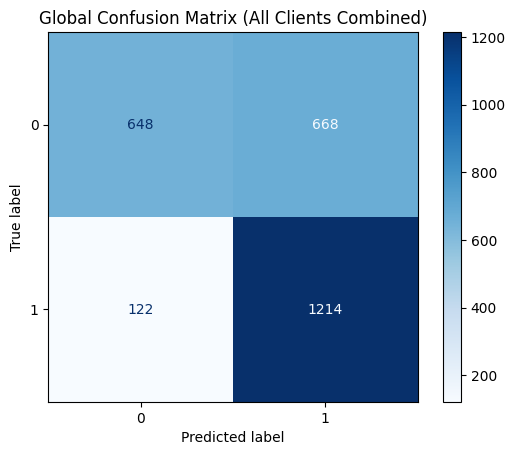


Final Global Accuracy (thr=0.35): 0.7021

[Global Classification Report]
              precision    recall  f1-score   support

           0     0.8416    0.4924    0.6213      1316
           1     0.6451    0.9087    0.7545      1336

    accuracy                         0.7021      2652
   macro avg     0.7433    0.7005    0.6879      2652
weighted avg     0.7426    0.7021    0.6884      2652



In [7]:
# ============================================================
# Federated Learning (TabNet) + αᵢ Mitigation + SMOTE + FocalLoss + Threshold Auto-Tuning
# ============================================================
# 오버샘플링이긴 한데 smote 기법 써서 올리는 것 기준
import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']


# ------------------------------------------------
# 1) 데이터 로드 + SMOTE 적용
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]

    #  SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res


def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    clients, metas = {}, {}

    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test], generator=torch.Generator().manual_seed(42))
        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {"n_samples": len(y), "class_counts": pd.Series(v["y"]).value_counts().to_dict()}

    return clients, metas, list(cols)


# ------------------------------------------------
# 2) TabNet 구조 정의
# ------------------------------------------------
def sparsemax(logits, dim=-1):
    z = logits
    z_sorted, _ = torch.sort(z, dim=dim, descending=True)
    dim_size = z.size(dim)
    range_vals = torch.arange(1, dim_size + 1, device=z.device, dtype=z.dtype).view(*([1] * (z.dim() - 1)), dim_size)
    zs_cumsum = torch.cumsum(z_sorted, dim=dim)
    k = (1 + range_vals * z_sorted > zs_cumsum).type(z.dtype)
    k_max = torch.max(range_vals * k, dim=dim, keepdim=True)[0]
    zs_cumsum_k = torch.gather(zs_cumsum, dim, (k_max.long() - 1))
    tau = (zs_cumsum_k - 1) / k_max
    output = torch.clamp(z - tau, min=0)
    return output


class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2)
    def forward(self, x):
        x = self.fc(x)
        x = self.bn(x)
        out, gate = x.chunk(2, dim=-1)
        return out * torch.sigmoid(gate)


class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, n_d, n_a, n_shared=1, n_independent=1):
        super().__init__()
        self.n_d, self.n_a = n_d, n_a
        self.shared = nn.ModuleList()
        for i in range(n_shared):
            in_dim = input_dim if i == 0 else n_d + n_a
            self.shared.append(GLUBlock(in_dim, n_d + n_a))
        self.indep = nn.ModuleList()
        for _ in range(n_independent):
            self.indep.append(GLUBlock(n_d + n_a, n_d + n_a))
    def forward(self, x):
        out = x
        for block in self.shared: out = block(out)
        for block in self.indep: out = block(out)
        return out


class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, feature_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)
    def forward(self, x, prior):
        x = self.fc(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = x * prior
        mask = sparsemax(x, dim=-1)
        return mask


class SimpleTabNet(nn.Module):
    def __init__(self, input_dim, num_classes=2, n_d=16, n_a=16, n_steps=3, gamma=1.3):
        super().__init__()
        self.input_dim, self.num_classes = input_dim, num_classes
        self.n_d, self.n_a, self.n_steps, self.gamma = n_d, n_a, n_steps, gamma
        self.decision_layers = nn.ModuleList([FeatureTransformer(input_dim, n_d, n_a) for _ in range(n_steps)])
        self.att = AttentiveTransformer(n_d, input_dim)
        self.fc_out = nn.Linear(n_d, num_classes)
    def forward(self, x):
        batch_size = x.size(0)
        prior = torch.ones(batch_size, self.input_dim, device=x.device)
        aggregated = torch.zeros(batch_size, self.n_d, device=x.device)
        x_flat, decision = x, None
        for step in range(self.n_steps):
            mask = sparsemax(x_flat, dim=-1) if step == 0 else self.att(decision, prior)
            masked_x = x_flat * mask
            h = self.decision_layers[step](masked_x)
            d, a = h[:, :self.n_d], h[:, self.n_d:]
            decision = d
            aggregated += decision
            prior = prior * (self.gamma - mask)
        return self.fc_out(aggregated)


# ------------------------------------------------
# 3) Focal Loss 정의
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')
    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()


# ------------------------------------------------
# 4) αᵢ 계산 및 Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K, total = len(class_counts), sum(class_counts.values())
    if K == 0 or total == 0: return 1e-8
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)
    logK = math.log(K + 1e-12)
    H_tilde = max(H, eps_frac * logK)
    frac_k = sum(1 for c in class_counts.values() if c >= min_samples) / K
    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components, rho=1.0, beta=0.7, theta=0.5):
    if not state_dicts: return None
    logits = {cid: math.log(comp["n_i"] ** rho + 1e-12)
                   + math.log(comp["c_i"] ** beta + 1e-12)
                   + math.log(comp["t_i"] ** theta + 1e-12)
              for cid, comp in alpha_components.items()}
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}
    global_sd = None
    for cid, sd in state_dicts.items():
        w = alphas[cid]
        if global_sd is None:
            global_sd = {k: v.clone() * w for k, v in sd.items()}
        else:
            for k in global_sd: global_sd[k] += sd[k] * w
    return global_sd


# ------------------------------------------------
# 5) Local Train & Evaluate
# ------------------------------------------------
def local_train(model, dataset, lr, epochs, device):
    model = copy.deepcopy(model).to(device)
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = FocalLoss(alpha=2.0, gamma=2.0)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
    return model.state_dict()


def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()
    acc = (np.array(y_true) == np.array(y_pred)).mean()
    if return_preds: return acc, y_true, y_pred
    return acc


def find_best_threshold(model, dataset, device, thresholds=np.arange(0.3, 0.51, 0.05)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, y_true, y_pred = evaluate(model, dataset, device, threshold=t, return_preds=True)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t


# ------------------------------------------------
# 6) Main Loop
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = SimpleTabNet(input_dim=input_dim, num_classes=2).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    participation_log = {cid: 0 for cid in clients}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
    prev_global = copy.deepcopy(global_model.state_dict())

    round_log = {"round": [], "acc": [], "dW": []}
    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")
        selected = [cid for cid in clients if random.random() < participation_probs[cid]] or [random.choice(list(clients.keys()))]
        for cid in selected: participation_log[cid] += 1
        state_dicts, alpha_components = {}, {}
        before_acc = evaluate(global_model, combined_test, device)

        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()
            state_dict = local_train(global_model, ds, lr=0.001, epochs=5, device=device)
            state_dicts[cid] = state_dict
            alpha_components[cid] = {
                "n_i": math.sqrt(metas[cid]["n_samples"]),
                "c_i": compute_ci(class_counts),
                "t_i": participation_probs[cid]
            }

        new_global = aggregate_with_softmax_weights(state_dicts, alpha_components)
        if new_global: global_model.load_state_dict(new_global)

        after_acc, y_true, y_pred = evaluate(global_model, combined_test, device, return_preds=True)
        dW = np.mean([
            torch.norm(global_model.state_dict()[k] - prev_global[k]).item()
            for k in global_model.state_dict().keys()
            if global_model.state_dict()[k].dtype in (torch.float32, torch.float64)
        ])
        prev_global = copy.deepcopy(global_model.state_dict())

        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f} | ΔW={dW:.4f}")
        round_log["round"].append(rnd); round_log["acc"].append(after_acc); round_log["dW"].append(dW)

    # ------------------------------------------------
    # 7) Global Evaluation + Threshold Auto-Tuning
    # ------------------------------------------------
    print("\n===============================")
    print(" Global Model Evaluation (All Clients Combined)")
    print("===============================")
    best_t = find_best_threshold(global_model, combined_test, device)

    global_acc, global_y_true, global_y_pred = evaluate(global_model, combined_test, device, return_preds=True, threshold=best_t)
    cm = confusion_matrix(global_y_true, global_y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Global Confusion Matrix (All Clients Combined)")
    plt.show()

    print(f"\nFinal Global Accuracy (thr={best_t:.2f}): {global_acc:.4f}")
    print("\n[Global Classification Report]")
    print(classification_report(global_y_true, global_y_pred, digits=4))


[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5038 → 0.5502 | ΔW=1.3129

=== Round 2 ===
[Round 2] Global Accuracy: 0.5502 → 0.6097 | ΔW=0.1217

=== Round 3 ===
[Round 3] Global Accuracy: 0.6097 → 0.6018 | ΔW=0.0984

=== Round 4 ===
[Round 4] Global Accuracy: 0.6018 → 0.6233 | ΔW=0.1191

=== Round 5 ===
[Round 5] Global Accuracy: 0.6233 → 0.6324 | ΔW=0.0733

=== Round 6 ===
[Round 6] Global Accuracy: 0.6324 → 0.6176 | ΔW=0.1012

=== Round 7 ===
[Round 7] Global Accuracy: 0.6176 → 0.6176 | ΔW=0.0819

=== Round 8 ===
[Round 8] Global Accuracy: 0.6176 → 0.6278 | ΔW=0.0663

=== Round 9 ===
[Round 9] Global Accuracy: 0.6278 → 0.6233 | ΔW=0.0698

=== Round 10 ===
[Round 10] Global Accuracy: 

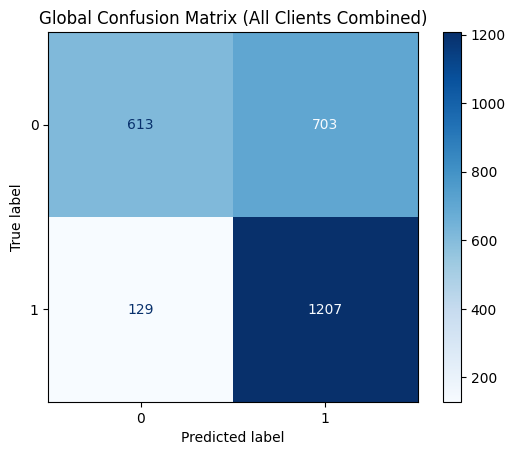


Final Global Accuracy (thr=0.40): 0.6863

[Global Classification Report]
              precision    recall  f1-score   support

           0     0.8261    0.4658    0.5957      1316
           1     0.6319    0.9034    0.7437      1336

    accuracy                         0.6863      2652
   macro avg     0.7290    0.6846    0.6697      2652
weighted avg     0.7283    0.6863    0.6703      2652


 Per-Client Fine-tuning (Personalization)

--- Client A Fine-tuning ---
[Client A] Fine-tuned Accuracy: 0.7132
[Client {cid}] Fine-tuned Classification Report:
              precision    recall  f1-score   support

           0     0.8900    0.4859    0.6286       566
           1     0.6468    0.9400    0.7664       567

    accuracy                         0.7132      1133
   macro avg     0.7684    0.7130    0.6975      1133
weighted avg     0.7683    0.7132    0.6975      1133


--- Client B Fine-tuning ---
[Client B] Fine-tuned Accuracy: 0.7368
[Client {cid}] Fine-tuned Classification R

In [8]:
# ============================================================
# Federated Learning (TabNet) + αᵢ Mitigation
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation + Fine-tuning
# ============================================================
# FedProx + FedBN + Fine-tuning 적용 버전
import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']


# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    # 결함 라벨 없으면 0으로 채우기
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 여러 결함 라벨 → 이진 라벨
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처 생성
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')    # 결측 포함 행 제거
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res


def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 공통 피처만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)

        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test],
                              generator=torch.Generator().manual_seed(42))

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)


# ------------------------------------------------
# 2) TabNet 구조 정의 (Simple 버전)
# ------------------------------------------------
def sparsemax(logits, dim=-1):
    z = logits
    z_sorted, _ = torch.sort(z, dim=dim, descending=True)
    dim_size = z.size(dim)
    range_vals = torch.arange(
        1, dim_size + 1,
        device=z.device,
        dtype=z.dtype
    ).view(*([1] * (z.dim() - 1)), dim_size)
    zs_cumsum = torch.cumsum(z_sorted, dim=dim)
    k = (1 + range_vals * z_sorted > zs_cumsum).type(z.dtype)
    k_max = torch.max(range_vals * k, dim=dim, keepdim=True)[0]
    zs_cumsum_k = torch.gather(zs_cumsum, dim, (k_max.long() - 1))
    tau = (zs_cumsum_k - 1) / k_max
    output = torch.clamp(z - tau, min=0)
    return output


class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2)

    def forward(self, x):
        x = self.fc(x)
        x = self.bn(x)
        out, gate = x.chunk(2, dim=-1)
        return out * torch.sigmoid(gate)


class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, n_d, n_a, n_shared=1, n_independent=1):
        super().__init__()
        self.n_d, self.n_a = n_d, n_a
        self.shared = nn.ModuleList()
        for i in range(n_shared):
            in_dim = input_dim if i == 0 else n_d + n_a
            self.shared.append(GLUBlock(in_dim, n_d + n_a))
        self.indep = nn.ModuleList()
        for _ in range(n_independent):
            self.indep.append(GLUBlock(n_d + n_a, n_d + n_a))

    def forward(self, x):
        out = x
        for block in self.shared:
            out = block(out)
        for block in self.indep:
            out = block(out)
        return out


class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, feature_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)

    def forward(self, x, prior):
        x = self.fc(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = x * prior
        mask = sparsemax(x, dim=-1)
        return mask


class SimpleTabNet(nn.Module):
    def __init__(self,
                 input_dim,
                 num_classes=2,
                 n_d=16,
                 n_a=16,
                 n_steps=3,
                 gamma=1.3):
        super().__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.n_d, self.n_a = n_d, n_a
        self.n_steps, self.gamma = n_steps, gamma

        self.decision_layers = nn.ModuleList(
            [FeatureTransformer(input_dim, n_d, n_a) for _ in range(n_steps)]
        )
        self.att = AttentiveTransformer(n_d, input_dim)
        self.fc_out = nn.Linear(n_d, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        prior = torch.ones(batch_size, self.input_dim, device=x.device)
        aggregated = torch.zeros(batch_size, self.n_d, device=x.device)

        x_flat = x
        decision = None

        for step in range(self.n_steps):
            if step == 0:
                mask = sparsemax(x_flat, dim=-1)
            else:
                mask = self.att(decision, prior)

            masked_x = x_flat * mask
            h = self.decision_layers[step](masked_x)
            d, a = h[:, :self.n_d], h[:, self.n_d:]

            decision = d
            aggregated = aggregated + decision
            prior = prior * (self.gamma - mask)

        logits = self.fc_out(aggregated)
        return logits


# ------------------------------------------------
# 3) Focal Loss (불균형 완화)
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# ------------------------------------------------
# 4) αᵢ 구성요소 (nᵢ, cᵢ) + FedBN 스타일 Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = 0.0
    for c in class_counts.values():
        if c > 0:
            p = c / total
            H -= p * math.log(p)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K
    ci = max(1e-8, frac_k * (H_tilde / logK))
    return ci


def aggregate_with_softmax_weights(state_dicts,
                                   alpha_components,
                                   rho=1.0,
                                   beta=0.7,
                                   theta=0.5,
                                   use_fedbn=True):
    """
    FedBN 스타일:
      - BatchNorm 관련 파라미터(running_mean, running_var, num_batches_tracked, 'bn' 포함)는 평균 안 내고
        기준 클라이언트(A 등)의 것을 그대로 사용
      - 나머지 파라미터는 αᵢ 가중 softmax 평균
    """
    if not state_dicts:
        return None

    client_ids = list(state_dicts.keys())

    # αᵢ 계산
    logits = {}
    for cid, comp in alpha_components.items():
        log_weight = (
            math.log(comp["n_i"] ** rho + 1e-12) +
            math.log(comp["c_i"] ** beta + 1e-12) +
            math.log(comp["t_i"] ** theta + 1e-12)
        )
        logits[cid] = log_weight

    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = state_dicts[client_ids[0]]
    global_sd = {}

    for k in base_sd.keys():
        # FedBN: BN 관련 파라미터는 평균 내지 않고 기준 클라이언트 것 사용
        if use_fedbn and (
            "bn" in k or
            "running_mean" in k or
            "running_var" in k or
            "num_batches_tracked" in k
        ):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = None
            for cid, sd in state_dicts.items():
                w = alphas[cid]
                t = sd[k] * w
                if agg is None:
                    agg = t.clone()
                else:
                    agg += t
            global_sd[k] = agg

    return global_sd


# ------------------------------------------------
# 5) Local Train (FedProx 지원) + Evaluate + Threshold Search
# ------------------------------------------------
def local_train(base_model,
                dataset,
                lr,
                epochs,
                device,
                global_params=None,
                mu=0.0):
    """
    base_model: 서버에서 받은 글로벌 모델
    global_params: FedProx용 글로벌 파라미터 리스트 (None이면 Prox 적용 안함)
    mu: FedProx 계수 (0이면 일반 로컬 학습)
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    if global_params is not None and mu > 0.0:
        global_params = [p.detach().clone().to(device) for p in global_params]
    else:
        global_params = None

    crit = FocalLoss(alpha=2.0, gamma=2.0)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx 항 추가
            if global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    acc = (y_true_np == y_pred_np).mean()

    if return_preds:
        return acc, y_true, y_pred
    return acc


def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.3, 0.51, 0.05)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, y_true, y_pred = evaluate(model, dataset, device,
                                     threshold=t,
                                     return_preds=True)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t


# ------------------------------------------------
# 6) 메인 루프 + Fine-tuning
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    parser.add_argument("--mu", type=float, default=0.01, help="FedProx mu")
    parser.add_argument("--ft_epochs", type=int, default=3, help="Fine-tuning epochs per client")
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = SimpleTabNet(input_dim=input_dim, num_classes=2).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    participation_log = {cid: 0 for cid in clients}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
    prev_global = copy.deepcopy(global_model.state_dict())

    round_log = {"round": [], "acc": [], "dW": []}

    # ===================== Federated Rounds =====================
    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        # 라운드별 참여 클라이언트 선택
        selected = [cid for cid in clients
                    if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        for cid in selected:
            participation_log[cid] += 1

        state_dicts, alpha_components = {}, {}

        before_acc = evaluate(global_model, combined_test, device)

        # FedProx용 글로벌 파라미터 백업
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 로컬 학습
        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()

            state_dict = local_train(
                base_model=global_model,
                dataset=ds,
                lr=0.001,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = state_dict

            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        # FedBN 스타일 Aggregation
        new_global = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=1.0,
            beta=0.7,
            theta=0.5,
            use_fedbn=True
        )
        if new_global is None:
            continue

        global_model.load_state_dict(new_global)

        after_acc, y_true, y_pred = evaluate(
            global_model, combined_test, device,
            return_preds=True
        )

        # ΔW 계산 (non-BN 파라미터 기준)
        dWs = []
        for k in global_model.state_dict().keys():
            if global_model.state_dict()[k].dtype in (torch.float32, torch.float64):
                diff = global_model.state_dict()[k] - prev_global[k]
                dWs.append(torch.norm(diff).item())
        dW = float(np.mean(dWs)) if len(dWs) > 0 else 0.0
        prev_global = copy.deepcopy(global_model.state_dict())

        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f} | ΔW={dW:.4f}")
        round_log["round"].append(rnd)
        round_log["acc"].append(after_acc)
        round_log["dW"].append(dW)

    # ===================== Global Evaluation =====================
    print("\n===============================")
    print(" Global Model Evaluation (All Clients Combined)")
    print("===============================")

    best_t = find_best_threshold(global_model, combined_test, device)

    global_acc, global_y_true, global_y_pred = evaluate(
        global_model, combined_test, device,
        return_preds=True, threshold=best_t
    )

    cm = confusion_matrix(global_y_true, global_y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Global Confusion Matrix (All Clients Combined)")
    plt.show()

    print(f"\nFinal Global Accuracy (thr={best_t:.2f}): {global_acc:.4f}")
    print("\n[Global Classification Report]")
    print(classification_report(global_y_true, global_y_pred, digits=4))

    # ===================== Per-Client Fine-tuning =====================
    print("\n===============================")
    print(" Per-Client Fine-tuning (Personalization)")
    print("===============================")

    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")

        # 글로벌 모델을 초기값으로 사용, FedProx 없이 로컬 추가 학습
        ft_state = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.001,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,
            mu=0.0
        )

        local_model = copy.deepcopy(global_model).to(device)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(
            local_model,
            data["test"],
            device,
            threshold=best_t,
            return_preds=True
        )

        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print("[Client {cid}] Fine-tuned Classification Report:")
        print(classification_report(yt_c, yp_c, digits=4))
